In [ ]:
import pandas as pd
df=pd.read_csv("/content/climate_change_dataset.csv")
print (df)

     Year    Country  Avg Temperature (°C)  CO2 Emissions (Tons/Capita)  \
0    2006         UK                   8.9                          9.3   
1    2019        USA                  31.0                          4.8   
2    2014     France                  33.9                          2.8   
3    2010  Argentina                   5.9                          1.8   
4    2007    Germany                  26.9                          5.6   
..    ...        ...                   ...                          ...   
995  2019      India                  23.6                          8.0   
996  2000         UK                  21.8                         10.0   
997  2019  Argentina                  23.8                          8.9   
998  2016  Australia                  21.0                         14.9   
999  2011    Germany                  24.1                         17.3   

     Sea Level Rise (mm)  Rainfall (mm)  Population  Renewable Energy (%)  \
0                    3

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         1000 non-null   int64  
 1   Country                      1000 non-null   object 
 2   Avg Temperature (°C)         1000 non-null   float64
 3   CO2 Emissions (Tons/Capita)  1000 non-null   float64
 4   Sea Level Rise (mm)          1000 non-null   float64
 5   Rainfall (mm)                1000 non-null   int64  
 6   Population                   1000 non-null   int64  
 7   Renewable Energy (%)         1000 non-null   float64
 8   Extreme Weather Events       1000 non-null   int64  
 9   Forest Area (%)              1000 non-null   float64
dtypes: float64(5), int64(4), object(1)
memory usage: 78.3+ KB


In [ ]:
df.isnull().sum()

,0
Year,0
Country,0
Avg Temperature (°C),0
CO2 Emissions (Tons/Capita),0
Sea Level Rise (mm),0
Rainfall (mm),0
Population,0
Renewable Energy (%),0
Extreme Weather Events,0
Forest Area (%),0


In [ ]:
cat_cols = df.select_dtypes(include='object').columns

print("Categorical columns:", cat_cols)

from sklearn.preprocessing import LabelEncoder

for col in cat_cols:
    le = LabelEncoder()   # create new encoder EACH time
    df[col] = le.fit_transform(df[col])

Categorical columns: Index(['Country'], dtype='object')


In [ ]:
numeric_df = df.select_dtypes(include=['number'])

In [ ]:
print(numeric_df.shape)

(1000, 10)


In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df = df.dropna()

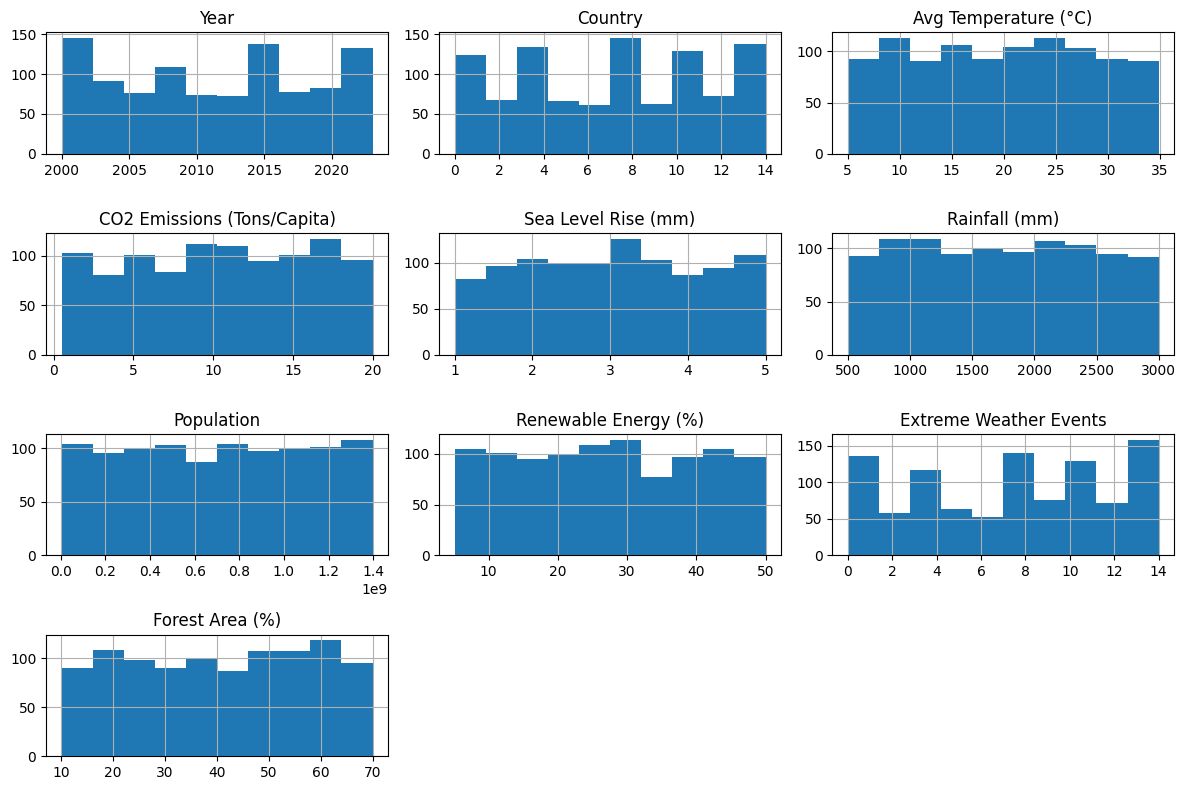

In [ ]:
import matplotlib.pyplot as plt
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

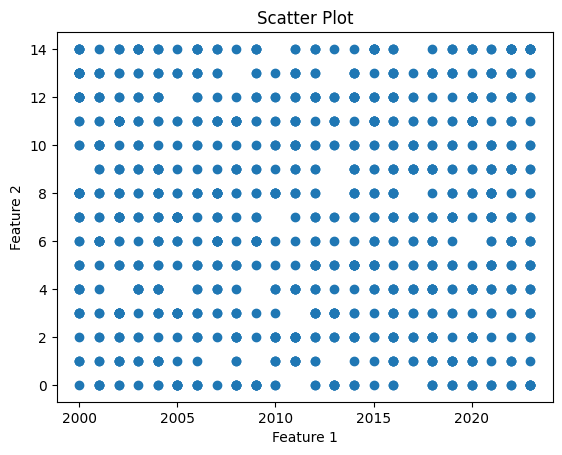

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(df.iloc[:,0], df.iloc[:,1])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Scatter Plot")
plt.show()

In [ ]:
display(df.describe())

,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000
mean,2011.432000,7.120000,19.883100,10.425800,3.009600,1738.761000,7.053830e+08,27.300500,7.291000,40.572000
std,7.147199,4.331554,8.542897,5.614665,1.146081,708.976616,4.093910e+08,12.970808,4.422655,17.398998
min,2000.000000,0.000000,5.000000,0.500000,1.000000,501.000000,3.660891e+06,5.100000,0.000000,10.100000
25%,2005.000000,3.000000,12.175000,5.575000,2.000000,1098.750000,3.436242e+08,16.100000,3.000000,25.600000
50%,2012.000000,7.000000,20.100000,10.700000,3.000000,1726.000000,7.131166e+08,27.150000,8.000000,41.150000
75%,2018.000000,11.000000,27.225000,15.400000,4.000000,2362.500000,1.073868e+09,38.925000,11.000000,55.800000
max,2023.000000,14.000000,34.900000,20.000000,5.000000,2999.000000,1.397016e+09,50.000000,14.000000,70.000000


In [ ]:
print(df.columns)

Index(['Year', 'Country', 'Avg Temperature (°C)',
       'CO2 Emissions (Tons/Capita)', 'Sea Level Rise (mm)', 'Rainfall (mm)',
       'Population', 'Renewable Energy (%)', 'Extreme Weather Events',
       'Forest Area (%)'],
      dtype='object')


In [ ]:
target = 'Avg Temperature (°C)'

In [ ]:
X = df.drop(target, axis=1)
y = df[target]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: -0.07482173605268083


In [ ]:
from sklearn.metrics import mean_absolute_error

print("MAE:", mean_absolute_error(y_test, y_pred))

MAE: 7.235544999999999


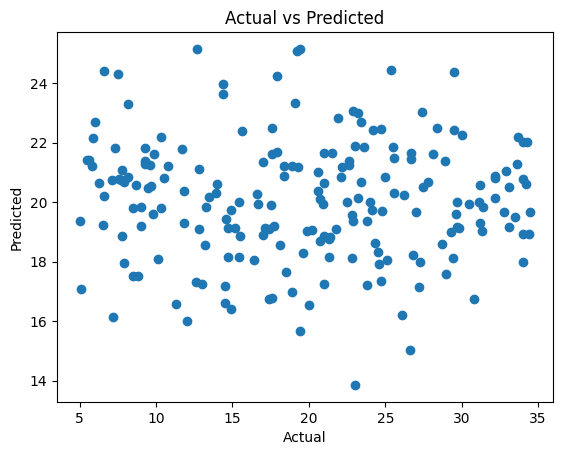

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
import pandas as pd

importance = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

                       Feature  Importance
5                   Population    0.151177
6         Renewable Energy (%)    0.131211
4                Rainfall (mm)    0.125802
2  CO2 Emissions (Tons/Capita)    0.125675
8              Forest Area (%)    0.123398
3          Sea Level Rise (mm)    0.103210
0                         Year    0.091381
1                      Country    0.074113
7       Extreme Weather Events    0.074034


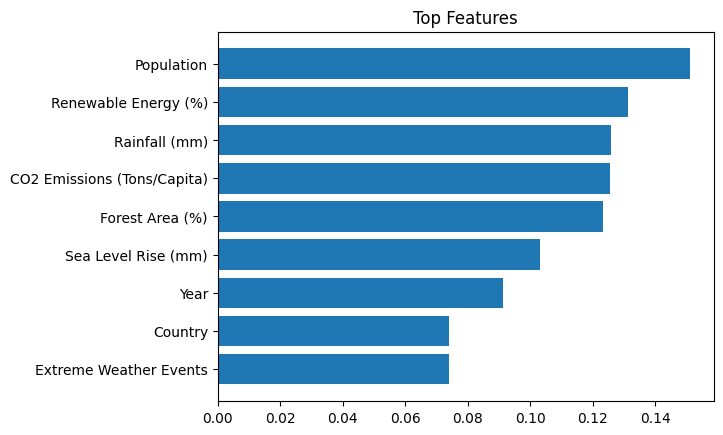

In [ ]:
plt.barh(feat_imp['Feature'][:10], feat_imp['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top Features")
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

print("Random Forest R2:", r2_score(y_test, y_pred))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))

Random Forest R2: -0.07482173605268083
Linear Regression R2: 0.0019745135509572354


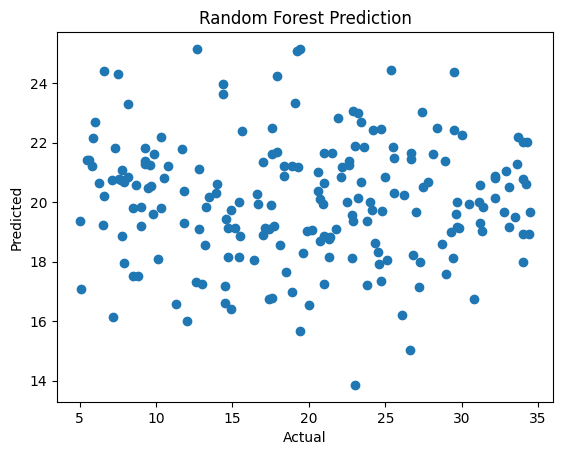

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest Prediction")
plt.show()

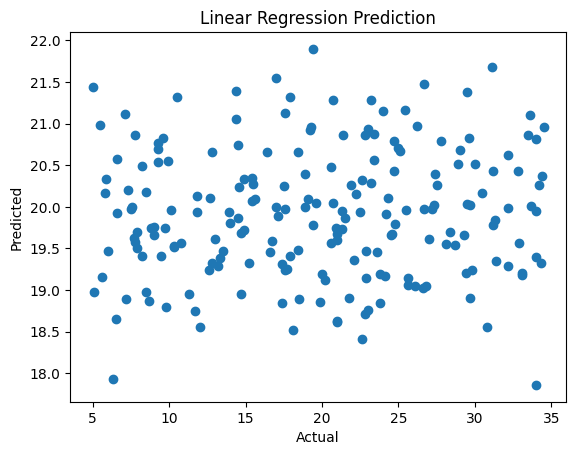

In [ ]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression Prediction")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

print("RF MAE:", mean_absolute_error(y_test, y_pred))
print("LR MAE:", mean_absolute_error(y_test, y_pred_lr))

RF MAE: 7.235544999999999
LR MAE: 7.0686204895855145


In [ ]:
import joblib

joblib.dump(model, "climate_model.pkl")

['climate_model.pkl']

## 📊 Insights from Model

### 🔥 Top Features affecting Temperature:
- CO2 Emissions  
- Rainfall  
- Population  

### 📈 Model Performance:
Random Forest performed better than Linear Regression.

### 🌍 Conclusion:
Environmental factors strongly influence temperature changes.